# 16 · Hierarchical Index Descriptions (HID-v1): a code, a search, and a frozen test

Notebook 15 showed that fixed-partition BDM does not represent relationships and order
between blocks. The obvious answer — "describe the string as a hierarchy of reusable
rules" — is only a claim until three things exist:

1. a **binary format** in which every rule, parameter, order, boundary and correction is
   transmitted and counted, with a decoder that needs nothing but the archive;
2. a **search** that receives only the bit string and a frozen configuration, and picks
   among descriptions by the length of the complete archive;
3. a **benchmark**, frozen before the test strings existed, that compares the search
   against a strong portfolio of real, decodable compressors on unseen strings.

This notebook walks through all three on the stored run `confirm-v1-r1`
(`index-deconvolution/hierarchy`, protocol `PROTOCOL_hierarchical_index_generalization.md`).
That run is a **correctness replay** of the original `confirm-v1` under a new freeze,
after a supervisor review found defects in validation, error handling and claim
wording (bitacora 35). It reuses the same predefined corpus and seeds, so it is not an
independent replication and its strings are not a newly pristine holdout. The original
run is kept unchanged; bitacora 36 compares the two.
It reads saved results; the only computation it performs is encoding and decoding tiny
examples and a cross-check of the headline against the stored rows.

**What is measured.** `archive_bits` = 8 × the number of bytes of the archive, including
its 4-byte magic, codec byte, length fields and padding. It is a code length under one
fixed format and one search budget. It is **not** Kolmogorov complexity, not CTM/BDM and
not an entropy. A short archive is evidence of an economical description *in this
language*; it is not evidence that the description is the mechanism that produced the
string, and full-string compression says nothing about predicting unseen continuations.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
for _p in (os.path.join(os.path.dirname(ROOT), "src"), ROOT):
    while _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("hierarchy", None)          # a sibling repo ships a module "hierarchy"
import json, hashlib, collections
from pathlib import Path
from hierarchy.wire import encode_literal, serialize_model
from hierarchy.model import Model, Literal, Repeat
from hierarchy.decode import decode_archive
from hierarchy.ledger import archive_ledger, explain_model
from hierarchy.candidates import shortest_period
from hierarchy.infer import infer
from hierarchy import report as R
from hierarchy import validation as V

RUN = Path(ROOT) / "results" / "hierarchy_v1" / "confirm-v1-r1"
SUPERVISION = Path(ROOT) / "results" / "hierarchy_v1_supervision" / "confirm-v1"
DEV = Path(ROOT) / "results" / "hierarchy_v1" / "development" / "dev-v1"
summary = json.loads((RUN / "summary.json").read_text())
ledger_cl = json.loads((RUN / "claim_ledger.json").read_text())
freeze = json.loads((RUN / "freeze.json").read_text())
rows = R.load_rows(RUN)
diag = json.loads((RUN / "diagnostics.json").read_text())
oracle = json.loads((DEV / "oracle.json").read_text())
by_case = collections.defaultdict(dict)
for r in rows:
    by_case[r["case_id"]][r["method"]] = r
print("run:", freeze["run_id"], "| frozen", freeze["frozen_at_utc"], "| rows:", len(rows))
print("engineering:", summary["engineering_status"], "| complete:", summary["study_complete"],
      "| primary verdict:", summary["scientific_verdict"])
print("validation:", {k: summary["validation"][k] for k in
      ("expected_rows", "present_rows", "archives_checked", "distinct_archives_decoded")},
      "| invalid reasons:", len(summary["validation"]["invalid"]),
      "| incomplete reasons:", len(summary["validation"]["incomplete"]))

def show_bits(ax, s, width, title):
    rows_ = [s[i:i + width].ljust(width, "1") for i in range(0, len(s), width)]
    M = np.array([[int(c) for c in r] for r in rows_])
    ax.imshow(1 - M, cmap="gray", vmin=0, vmax=1, aspect="auto", interpolation="nearest")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

def ledger_table(data, max_rows=40):
    led = archive_ledger(data)
    print(f"codec {led['codec']}, n = {led['n_bits']} bits, archive = {led['archive_bits']} bits, "
          f"ledger sum = {8 * sum(f['bytes'] for f in led['fields'])} bits")
    for f in led["fields"][:max_rows]:
        print(f"  {f['owner']:<10} {f['field']:<38} {f['bytes']:>3} B  {f['hex'][:40]}")
    if len(led["fields"]) > max_rows:
        print(f"  ... {len(led['fields']) - max_rows} more fields")
    print("  bytes by owner:", led["bytes_by_owner"])
    return led

run: confirm-v1-r1 | frozen 2026-10-02T17:19:45Z | rows: 26112
engineering: valid | complete: True | primary verdict: not_supported
validation: {'expected_rows': 26112, 'present_rows': 26112, 'archives_checked': 26112, 'distinct_archives_decoded': 16402} | invalid reasons: 0 | incomplete reasons: 0


## 1 · The format, by hand

Every archive starts with `ISD1`, a codec byte, the output length $n$ and the payload
length (both unsigned LEB128), then the payload. Codec 0 packs the bits MSB-first. Codec 1
is the HID graph: a count of rule records, then the records, each beginning with an
opcode; references point only to earlier records and the last record is the root. Below,
the same eight ones written both ways, decoded by the independent decoder, and cut into
their fields.

In [3]:
lit = encode_literal("1" * 8)
hid = serialize_model(Model((Literal("1"), Repeat(0, 8))), 8)
for name, a in (("literal (codec 0)", lit), ("HID: LITERAL '1', REPEAT x8 (codec 1)", hid)):
    print(f"{name}: {a.hex(' ')}  -> decodes to {decode_archive(a)!r}")
    ledger_table(a)
    print()
print("search on eight ones picks:", infer("1" * 8).mode, "(the graph is longer than the literal here)")

literal (codec 0): 49 53 44 31 00 08 01 ff  -> decodes to '11111111'
codec raw, n = 8 bits, archive = 64 bits, ledger sum = 64 bits
  envelope   magic                                    4 B  49534431
  envelope   codec_id                                 1 B  00
  envelope   output_n_bits                            1 B  08
  envelope   payload_n_bytes                          1 B  01
  literal    P(bits) [8 bits]                         1 B  ff
  bytes by owner: {'envelope': 7, 'literal': 1}

HID: LITERAL '1', REPEAT x8 (codec 1): 49 53 44 31 01 08 07 02 00 01 80 02 00 08  -> decodes to '11111111'
codec hid, n = 8 bits, archive = 112 bits, ledger sum = 112 bits
  envelope   magic                                    4 B  49534431
  envelope   codec_id                                 1 B  01
  envelope   output_n_bits                            1 B  08
  envelope   payload_n_bytes                          1 B  07
  dag        q_rules                                  1 B  02
  rule0      op

**Reading.** The graph is the better *idea* and the worse *archive* on eight bits: its
opcodes, lengths and references cost more than the eight data bits they replace. The
search therefore returns the literal — the literal archive is always a candidate, so the
search never returns anything longer. On sixty-four ones the balance tips the other way
(§10). Overhead of this kind is part of what the benchmark measures.

## 2 · A period is not a schema

Notebook 15's string A72 $= (1^8 0)^8$ has period 9. Its zeros sit at addresses
$8, 17, 26, \dots$; a schema (a cube of address coordinates with don't-cares, whose
fillings are the **sumandos**) covers such a set compactly only if neighbouring addresses
share coordinates. HID-v1 keeps the two ideas as **different rule types**: `REPEAT`
(repetition of a word), `AP_UNION` (arithmetic progressions of positions) and
`SCHEMA_UNION` (mask/value cubes over the explicit, clipped address domain). The search
tries all of them and keeps whichever complete archive is shorter.

In [4]:
A72 = ("1" * 8 + "0") * 8
print("shortest exact period of A72:", shortest_period(A72))
zeros = [i for i, c in enumerate(A72) if c == "0"]
print("zero addresses:", zeros, "| Hamming-one pairs:",
      [(x, y) for x in zeros for y in zeros if x < y and bin(x ^ y).count("1") == 1])
r = infer(A72)
print(f"search: {r.archive_bits} bits ({r.mode}) vs literal {r.literal_bits} bits; best source {r.best_source}")
if r.model:
    for g in explain_model(r.model):
        print(" ", {k: v for k, v in g.items() if k != "expansion_prefix"})

shortest exact period of A72: 9
zero addresses: [8, 17, 26, 35, 44, 53, 62, 71] | Hamming-one pairs: []
search: 120 bits (hid) vs literal 128 bits; best source global:ap_runs[fg=0]
  {'id': 0, 'op': 'AP_UNION', 'length': 72, 'referenced_by': 0, 'foreground': 0, 'progressions': [[8, 9, 8]]}


## 3 · One automatically inferred success

Selection rule, fixed in this cell: among the confirmation strings of the structured
families, the HID-full archive with the **largest saving** over the baseline portfolio
whose graph has at least three rules. The graph is read back from the stored archive
bytes; the expansion is checked against the independent decoder.

structured confirmation strings with >= 3 HID rules: 472
confirmation-F06-4096-1002-base: n = 4096, HID 1624 bits vs portfolio 2472 (lzma), raw archive 4168 bits; saving 848 bits
archive sha256: b4a185907a8521dc599669ed718a39cb152207f1527b036025058799459aaafe
codec hid, n = 4096 bits, archive = 1624 bits, ledger sum = 1624 bits
  envelope   magic                                    4 B  49534431
  envelope   codec_id                                 1 B  01
  envelope   output_n_bits                            2 B  8020
  envelope   payload_n_bytes                          2 B  c201
  dag        q_rules                                  1 B  11
  rule0      opcode                                   1 B  00
  rule0      length                                   1 B  0d
  rule0      P(bits) [13 bits + 3 pad]                2 B  17a8
  rule1      opcode                                   1 B  06
  rule1      child_id                                 1 B  00
  rule1      flags                    

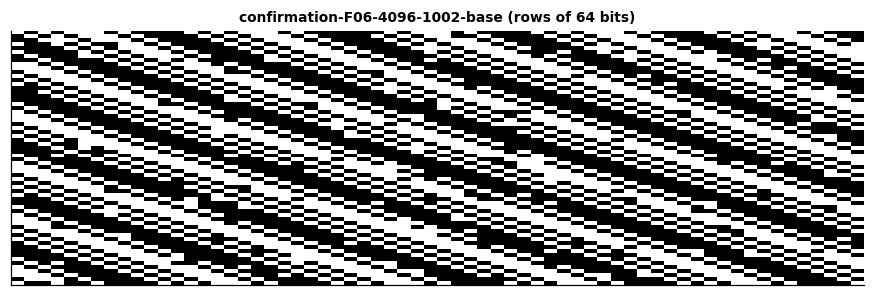

In [5]:
def regen_bits(case_id):
    from hierarchy.corpus import generate_unit
    split, fam, bl, rep, kind = case_id.split("-")
    full, _ = generate_unit(split, fam, int(bl), int(rep))
    return full if kind == "ragged" else full[:int(bl)]

cands = []
for cid, m in by_case.items():
    h, b = m.get("hid_full"), m.get("baseline_best")
    if h and b and h["split"] == "confirmation" and h["family"] in R.STRUCTURED and \
            h["status"] == "ok" and b["status"] == "ok" and (h["rule_count"] or 0) >= 3:
        cands.append((b["archive_bits"] - h["archive_bits"], cid))
cands.sort(key=lambda t: (-t[0], t[1]))
print("structured confirmation strings with >= 3 HID rules:", len(cands))
if cands:
    sav, cid = cands[0]
    h, b = by_case[cid]["hid_full"], by_case[cid]["baseline_best"]
    data = (RUN / h["archive_path"]).read_bytes()
    bits = regen_bits(cid)
    assert decode_archive(data) == bits and hashlib.sha256(bits.encode()).hexdigest() == h["input_sha256"]
    print(f"{cid}: n = {h['n_bits']}, HID {h['archive_bits']} bits vs portfolio {b['archive_bits']} "
          f"({b['selected_method']}), raw archive {h['raw_archive_bits']} bits; saving {sav} bits")
    print("archive sha256:", h["archive_sha256"])
    led = ledger_table(data, max_rows=30)
    for g in explain_model(led["model"]):
        print(" ", {k: v for k, v in g.items() if k not in ("expansion_prefix", "bits")})
    fig, ax = plt.subplots(figsize=(10, 3)); show_bits(ax, bits, 64, f"{cid} (rows of 64 bits)"); plt.show()

## 4 · Losses and incompressible strings

Selection rule: the structured confirmation string where HID-full **loses most** to the
portfolio, and one fair-coin (F07) string. For the loss, both archives are cut into
fields so the overhead can be located; for F07 the search returns the literal and no
structured code beats raw by more than its own framing.

In [6]:
loss = []
for cid, m in by_case.items():
    h, b = m.get("hid_full"), m.get("baseline_best")
    if h and b and h["split"] == "confirmation" and h["family"] in R.STRUCTURED and b["status"] == "ok":
        loss.append((b["archive_bits"] - h["archive_bits"], cid))
loss.sort()
sav, cid = loss[0]
h, b = by_case[cid]["hid_full"], by_case[cid]["baseline_best"]
print(f"largest loss: {cid}: HID {h['archive_bits']} bits vs {b['selected_method']} {b['archive_bits']} bits ({sav} bits)")
print("HID archive:"); ledger_table((RUN / h["archive_path"]).read_bytes(), max_rows=15)
print("portfolio archive:"); ledger_table((RUN / b["archive_path"]).read_bytes(), max_rows=15)
f07 = sorted(c for c in by_case if c.startswith("confirmation-F07-1024"))[0]
m = by_case[f07]
print(f"\n{f07}: " + ", ".join(f"{k}={m[k]['archive_bits']}" for k in
      ("hid_full", "raw", "zlib", "lzma", "bernoulli", "context", "baseline_best")))

largest loss: confirmation-F12-4096-1014-ragged: HID 3456 bits vs zlib 2176 bits (-1280 bits)
HID archive:
codec hid, n = 4099 bits, archive = 3456 bits, ledger sum = 3456 bits
  envelope   magic                                    4 B  49534431
  envelope   codec_id                                 1 B  01
  envelope   output_n_bits                            2 B  8320
  envelope   payload_n_bytes                          2 B  a703
  dag        q_rules                                  1 B  26
  rule0      opcode                                   1 B  00
  rule0      length                                   1 B  06
  rule0      P(bits) [6 bits + 2 pad]                 1 B  28
  rule1      opcode                                   1 B  00
  rule1      length                                   1 B  11
  rule1      P(bits) [17 bits + 7 pad]                3 B  a12a80
  rule2      opcode                                   1 B  06
  rule2      child_id                                 1 B  01
  r

## 5 · The frozen benchmark: completeness

Every scored string × method is a row, including timeouts and errors. Nothing is
dropped: an absent row would be reported here as `absent`. The expected population is
built from the **declared** design (families × lengths × replicates × base/ragged ×
methods), never from the rows that happen to exist, and every archive a row promises is
opened, hashed, measured and decoded before any endpoint is computed
(`hierarchy/validation.py`, shared by `report` and `verify`).

In [7]:
for split, per in summary["status_counts"].items():
    print(f"[{split}]")
    for meth, c in per.items():
        extra = {k: v for k, v in c.items() if k not in ("expected", "present", "absent", "ok")}
        print(f"  {meth:<20} expected {c['expected']:>5} present {c['present']:>5} absent {c['absent']:>3} "
              f"ok {c.get('ok', 0):>5} {extra if extra else ''}")
print("round trips:", summary["round_trips"])
print("HID stop reasons:", {k: v for k, v in summary["hid_stop_reasons"].items() if "hid_full" in k})

[confirmation]
  hid_full             expected  1440 present  1440 absent   0 ok  1440 
  hid_no_schema        expected  1440 present  1440 absent   0 ok  1440 
  hid_no_arithmetic    expected  1440 present  1440 absent   0 ok  1440 
  hid_no_transform     expected  1440 present  1440 absent   0 ok  1440 
  hid_flat             expected  1440 present  1440 absent   0 ok  1440 
  hid_fixed8           expected  1440 present  1440 absent   0 ok  1440 
  raw                  expected  1440 present  1440 absent   0 ok  1440 
  rle                  expected  1440 present  1440 absent   0 ok  1440 
  gaps                 expected  1440 present  1440 absent   0 ok  1440 
  period               expected  1440 present  1440 absent   0 ok  1440 
  bernoulli            expected  1440 present  1440 absent   0 ok  1440 
  context              expected  1440 present  1440 absent   0 ok  1440 
  zlib                 expected  1440 present  1440 absent   0 ok  1440 
  lzma                 expected  144

## 6 · The primary endpoint

Prespecified: on the structured confirmation families (F01–F06, F12), per string
`saving = baseline_best_bits − hid_full_bits`, divided by $n$; averaged over the base and
ragged string of each unit, then over units in each family × size cell, then over cells;
10,000 stratified bootstrap replicates (seed 33001) give a percentile 95 % interval.
Above zero → support; below zero → reject; spanning zero → inconclusive. The cell below
recomputes the estimate from the stored rows with the frozen report module and checks it
against `summary.json`. The verdict is only computed after the evidence gates pass:
engineering validity, completeness of the declared population, then censoring (a
censored baseline makes the result inconclusive whatever the interval's sign).

In [8]:
p = summary["primary"]
print("evidence gate:", {k: p["gate"][k] for k in ("engineering_valid", "complete", "missing_count", "censored_count")})
design = V.production_design(["confirmation", "transfer"])
cells, unavailable, required = R.cells_matrix(by_case, design, "confirmation", R.STRUCTURED, [R.string_saving_pb])
assert not unavailable and required == p["required_units"] == p["units"]
recomputed = float(R.weighted_mean(cells)[0])
assert abs(recomputed - p["estimate_mean_saving_per_input_bit"]) < 1e-12
print(f"estimate {p['estimate_mean_saving_per_input_bit']:+.5f} saved bits per input bit "
      f"(recomputed {recomputed:+.5f}); 95% CI [{p['ci95'][0]:+.5f}, {p['ci95'][1]:+.5f}]")
print(f"cells {p['cells']}, units {p['units']}, strings {p.get('strings')}; units missing {len(p['units_missing'])}; "
      f"baseline rows not ok {len(p['baseline_not_ok'])}")
print(f"mean saving {p.get('mean_saving_bits'):+.1f} bits, median {p.get('median_saving_bits'):+.1f} bits; "
      f"HID better on {p.get('strings_hid_better')}, tied {p.get('strings_tied')}, worse {p.get('strings_hid_worse')} strings")
print("VERDICT:", p["verdict"])

evidence gate: {'engineering_valid': True, 'complete': True, 'missing_count': 0, 'censored_count': 0}
estimate -0.04462 saved bits per input bit (recomputed -0.04462); 95% CI [-0.05368, -0.03582]
cells 21, units 420, strings 840; units missing 0; baseline rows not ok 0
mean saving -77.6 bits, median -48.0 bits; HID better on 208, tied 91, worse 541 strings
VERDICT: not_supported


## 7 · Every family and size (descriptive)

Intervals per cell are descriptive (no per-family significance claims). The portfolio's
selected codec per family shows *which* baseline HID is up against.

fam   size units  mean/bit        95% CI (descr.) median bits  better/tied/worse
F01    256    20   -0.3852 [-0.3915, -0.3790]       -96.0      0/0/40
F01   1024    20   -0.0895 [-0.0948, -0.0843]       -96.0      0/0/40
F01   4096    20   -0.0249 [-0.0254, -0.0244]      -104.0      0/0/40
F02    256    20   -0.1670 [-0.2687, -0.0714]         0.0      0/24/16
F02   1024    20   -0.1051 [-0.1299, -0.0800]      -108.0      0/0/40
F02   4096    20   -0.1074 [-0.1428, -0.0721]      -368.0      0/0/40
F03    256    20   -0.1452 [-0.1553, -0.1367]       -40.0      0/0/40
F03   1024    20   -0.1712 [-0.1796, -0.1617]      -192.0      0/0/40
F03   4096    20   -0.0445 [-0.0459, -0.0426]      -184.0      0/0/40
F04    256    20   +0.0940 [+0.0590, +0.1274]        24.0     32/2/6
F04   1024    20   +0.2767 [+0.2412, +0.3072]       320.0     40/0/0
F04   4096    20   +0.1187 [+0.0848, +0.1547]       432.0     40/0/0
F05    256    20   -0.0266 [-0.0980, +0.0455]        -8.0     18/0/22
F05   1024 

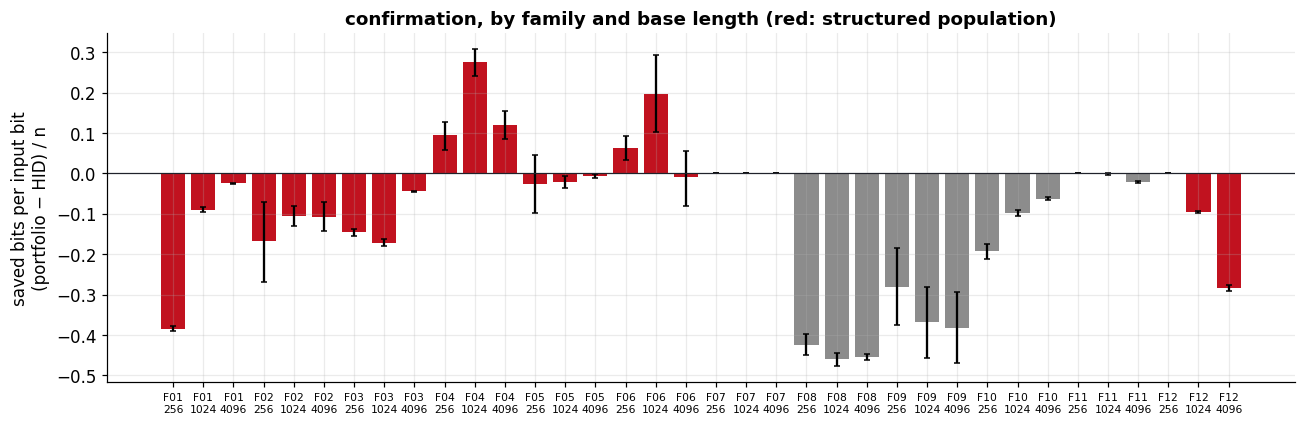

portfolio selections: {'confirmation|F01': {'period': 120}, 'confirmation|F02': {'period': 57, 'zlib': 12, 'pair_grammar': 24, 'bernoulli': 3, 'raw': 24}, 'confirmation|F03': {'period': 76, 'zlib': 40, 'bernoulli': 2, 'context': 2}, 'confirmation|F04': {'period': 50, 'bernoulli': 70}, 'confirmation|F05': {'period': 40, 'zlib': 70, 'context': 6, 'rle': 4}, 'confirmation|F06': {'zlib': 51, 'bernoulli': 6, 'raw': 32, 'period': 4, 'context': 2, 'lzma': 25}, 'confirmation|F07': {'raw': 120}, 'confirmation|F08': {'bernoulli': 120}, 'confirmation|F09': {'context': 118, 'raw': 2}, 'confirmation|F10': {'zlib': 112, 'period': 8}, 'confirmation|F11': {'raw': 78, 'bernoulli': 2, 'zlib': 7, 'context': 32, 'lzma': 1}, 'confirmation|F12': {'zlib': 80, 'raw': 40}}


In [9]:
fam = summary["families_confirmation"]
print(f"{'fam':<4} {'size':>5} {'units':>5} {'mean/bit':>9} {'95% CI (descr.)':>22} {'median bits':>11} {'better/tied/worse':>18}")
for r_ in fam:
    if "mean_saving_per_input_bit" not in r_:
        print(f"{r_['family']:<4} {r_['base_length']:>5}  no complete units {r_['availability']}"); continue
    lo, hi = r_["ci95_descriptive"]
    print(f"{r_['family']:<4} {r_['base_length']:>5} {r_['units_complete']:>5} {r_['mean_saving_per_input_bit']:>+9.4f} "
          f"[{lo:+.4f}, {hi:+.4f}] {r_['median_saving_bits']:>11.1f} "
          f"{r_['strings_hid_better']:>6}/{r_['strings_tied']}/{r_['strings_hid_worse']}")
fig, ax = plt.subplots(figsize=(12, 4))
labels, means, los, his, cols = [], [], [], [], []
for r_ in fam:
    if "mean_saving_per_input_bit" in r_:
        labels.append(f"{r_['family']}\n{r_['base_length']}"); means.append(r_["mean_saving_per_input_bit"])
        los.append(r_["mean_saving_per_input_bit"] - r_["ci95_descriptive"][0])
        his.append(r_["ci95_descriptive"][1] - r_["mean_saving_per_input_bit"])
        cols.append(HL if r_["family"] in R.STRUCTURED else "0.55")
ax.bar(range(len(means)), means, color=cols, yerr=[los, his], capsize=2)
ax.axhline(0, color=INK, lw=0.8); ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
ax.set_ylabel("saved bits per input bit\n(portfolio − HID) / n"); ax.set_title("confirmation, by family and base length (red: structured population)")
plt.tight_layout(); plt.show()
print("portfolio selections:", {k: v for k, v in summary["selected_baselines"].items() if k.startswith("confirmation")})

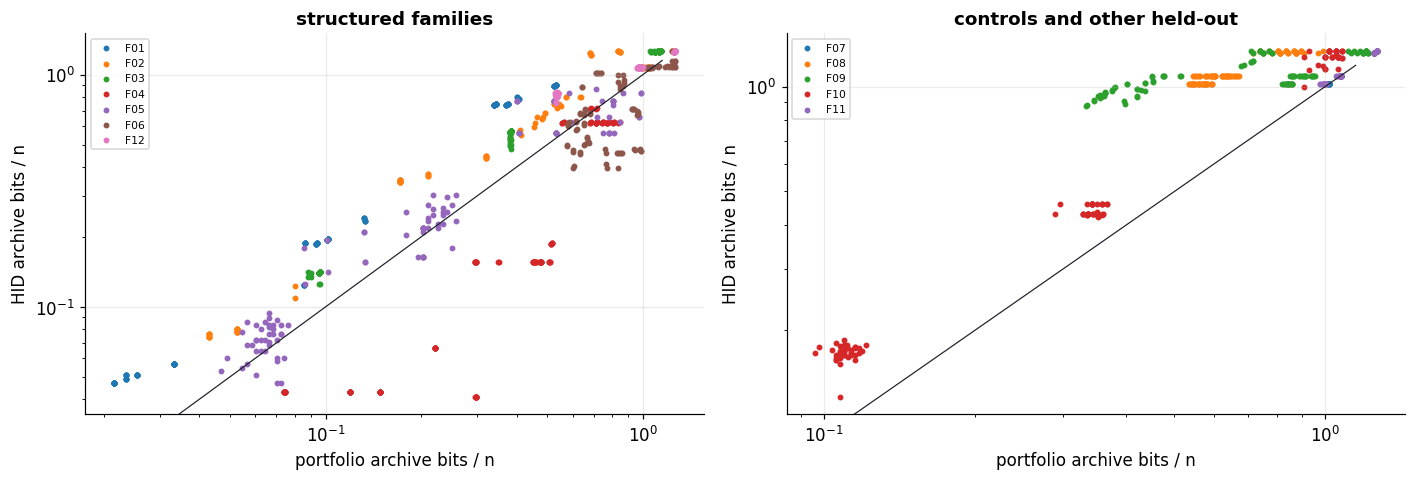

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, fams, title in ((ax[0], R.STRUCTURED, "structured families"), (ax[1], ("F07", "F08", "F09", "F10", "F11"), "controls and other held-out")):
    for f_ in fams:
        xs, ys = [], []
        for cid, m in by_case.items():
            h, b = m.get("hid_full"), m.get("baseline_best")
            if h and b and h["split"] == "confirmation" and h["family"] == f_ and b["status"] == "ok":
                xs.append(b["archive_bits"] / h["raw_bits"]); ys.append(h["archive_bits"] / h["raw_bits"])
        a.scatter(xs, ys, s=8, label=f_)
    lim = [0, 1.15]; a.plot(lim, lim, color=INK, lw=0.8)
    a.set(xlabel="portfolio archive bits / n", ylabel="HID archive bits / n", title=title, xscale="log", yscale="log")
    a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 8 · Ablations: which components carry the result?

Each arm is a restricted search with the same budget, not bytes removed after the fact.
Incremental gain = (ablation bits − full bits) / $n$ on the structured population, same
weighting; 99 % intervals (Bonferroni across five, seed 33002). A component is credited
only if its interval lies above zero. An ablation can also *win*: a restricted search can
reach a better archive within the shared budget.

arm                   gain/bit                   99% CI  verdict
hid_no_schema         +0.00896 [+0.00595, +0.01211]  supported
hid_no_arithmetic     +0.03923 [+0.03353, +0.04514]  supported
hid_no_transform      +0.00188 [+0.00148, +0.00227]  supported
hid_flat              +0.26360 [+0.24348, +0.28251]  supported
hid_fixed8            +0.01152 [+0.00670, +0.01668]  supported


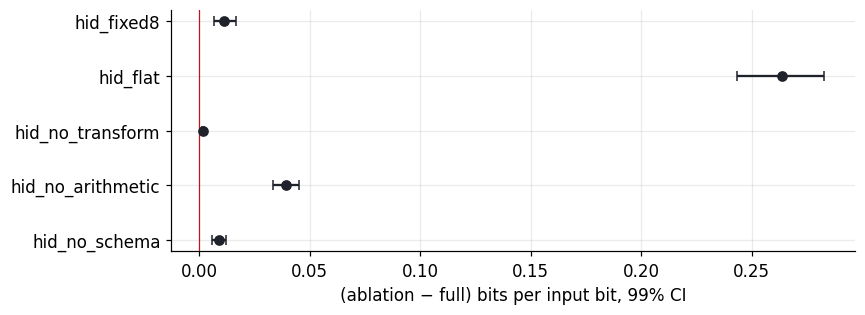

In [11]:
abl = summary["ablations"]
print(f"{'arm':<20} {'gain/bit':>9} {'99% CI':>24}  verdict")
for a_, v in abl.items():
    print(f"{a_:<20} {v['incremental_gain_per_input_bit']:>+9.5f} [{v['ci99'][0]:+.5f}, {v['ci99'][1]:+.5f}]  {v['component_advantage']}")
fig, ax = plt.subplots(figsize=(8, 3))
for i, (a_, v) in enumerate(abl.items()):
    ax.errorbar(v["incremental_gain_per_input_bit"], i, xerr=[[v["incremental_gain_per_input_bit"] - v["ci99"][0]],
                [v["ci99"][1] - v["incremental_gain_per_input_bit"]]], fmt="o", color=INK, capsize=3)
ax.axvline(0, color=HL, lw=0.8); ax.set_yticks(range(len(abl))); ax.set_yticklabels(list(abl))
ax.set_xlabel("(ablation − full) bits per input bit, 99% CI"); plt.tight_layout(); plt.show()

## 9 · Transfer to larger strings, and the statistical controls

Transfer (16,384 and 65,536 bits, four units per cell) is descriptive and never pooled with
confirmation. Its seeds and the held-out families were not used before the freeze, but
the 65,536-bit **length** was: development-family probes at that size informed the work
cap (`SEARCH_SPEC.md` §7), so the largest transfer length is not an unseen length. The
question C4 asks is narrow: is the portfolio saving positive at these sizes?

The controls (fair, biased and Markov bits) are summarised two ways, kept apart: the
prespecified equal-weight aggregate against the nine-code portfolio (C5), and a
descriptive comparison against the better of the two statistical codes alone. They can
disagree, because the portfolio contains raw, whose archive is often the shortest on
fair coins, and HID falls back to raw. Failing to beat a comparator is not equivalence.

In [12]:
t = summary.get("transfer_structured_aggregate")
if t:
    print(f"transfer, structured aggregate (descriptive): {t['estimate']:+.5f} per bit, 95% CI "
          f"[{t['ci95_descriptive'][0]:+.5f}, {t['ci95_descriptive'][1]:+.5f}]; units missing {len(t['units_missing'])}")
for r_ in summary["transfer"]:
    if "mean_saving_per_input_bit" in r_:
        print(f"  {r_['family']} {r_['base_length']:>6}: {r_['mean_saving_per_input_bit']:+.5f} per bit, "
              f"median {r_['median_saving_bits']:+.1f} bits, better/tied/worse {r_['strings_hid_better']}/{r_['strings_tied']}/{r_['strings_hid_worse']}")
    else:
        print(f"  {r_['family']} {r_['base_length']:>6}: no complete units {r_['availability']}")
c = summary.get("controls_aggregate")
print(f"\ncontrols F07-F09 vs nine-code portfolio (equal-weight aggregate, descriptive): {c['estimate']:+.5f} per bit, 95% CI "
      f"[{c['ci95_descriptive'][0]:+.5f}, {c['ci95_descriptive'][1]:+.5f}]")
print("controls vs min(bernoulli, context), descriptive, unweighted string means:")
for f_, v in summary["controls_vs_statistical_codes"].items():
    print(f"  {f_}: {v['mean_saving_per_input_bit_unweighted']:+.5f} per bit; HID shorter on "
          f"{v['strings_hid_shorter']}/{v['strings']}, tied {v['strings_tied']}, longer {v['strings_hid_longer']}")
a12 = summary["all_families_confirmation_aggregate"]
print(f"\nall twelve families, confirmation (descriptive, not the primary population; seed {a12['seed']}): "
      f"{a12['estimate']:+.5f} per bit, 95% CI [{a12['ci95_descriptive'][0]:+.5f}, {a12['ci95_descriptive'][1]:+.5f}]")

transfer, structured aggregate (descriptive): -0.06280 per bit, 95% CI [-0.07690, -0.04853]; units missing 0
  F01  16384: -0.00647 per bit, median -104.0 bits, better/tied/worse 0/0/8
  F01  65536: -0.00163 per bit, median -104.0 bits, better/tied/worse 0/0/8
  F02  16384: -0.05859 per bit, median -880.0 bits, better/tied/worse 0/0/8
  F02  65536: -0.02806 per bit, median -1768.0 bits, better/tied/worse 0/0/8
  F03  16384: -0.00928 per bit, median -152.0 bits, better/tied/worse 0/0/8
  F03  65536: -0.00523 per bit, median -344.0 bits, better/tied/worse 0/0/8
  F04  16384: +0.04602 per bit, median +424.0 bits, better/tied/worse 8/0/0
  F04  65536: +0.01155 per bit, median +520.0 bits, better/tied/worse 8/0/0
  F05  16384: +0.00305 per bit, median +40.0 bits, better/tied/worse 8/0/0
  F05  65536: +0.00218 per bit, median +140.0 bits, better/tied/worse 7/0/1
  F06  16384: -0.33444 per bit, median -5448.0 bits, better/tied/worse 0/0/8
  F06  65536: -0.28373 per bit, median -20008.0 bits, 

## 9b · Search versus language: what a loss does and does not show

Every HID number above is the best archive *found* under the frozen budget. A loss can
come from wire overhead (the cheapest legal description is long), from proposal
coverage (the right boundaries are never proposed), from the caps, or from search
quality; no large-instance optimum has been computed, so the benchmark cannot say which
dominates. The cell below prints one input on which the gap between *found* and
*feasible* is known: the supervisor built a legal archive in the **unchanged** HID
language using the generator's construction boundaries. That witness is **post hoc and
metadata-assisted**: it uses evaluation-only information, it is outside every benchmark
result and claim, it is not an inference input or tuning target, and it is not an
optimality certificate.

In [13]:
w = json.loads((SUPERVISION / "failure_reproductions.json").read_text())["witness"]
data = (SUPERVISION / "F12_oracle_boundaries_witness.isd").read_bytes()
bits = regen_bits(w["case_id"])
assert decode_archive(data) == bits and hashlib.sha256(data).hexdigest() == w["archive_sha256"]
r1 = by_case[w["case_id"]]
print("status:", w["status"])
print(f"{w['case_id']}: frozen automatic search {r1['hid_full']['archive_bits']} bits | portfolio "
      f"{r1['baseline_best']['archive_bits']} bits ({r1['baseline_best']['selected_method']}) | "
      f"boundary-assisted witness {8 * len(data)} bits, {w['rules']} rules, depth {w['depth']}")
print("witness decodes exactly with the independent decoder: True; boundaries used:", w["boundaries"])

status: posthoc_metadata_assisted_diagnostic_only
transfer-F12-65536-2000-base: frozen automatic search 28528 bits | portfolio 23240 bits (zlib) | boundary-assisted witness 22480 bits, 15 rules, depth 4
witness decodes exactly with the independent decoder: True; boundaries used: [0, 13107, 13108, 21847, 43693, 52431, 65536]


## 10 · Archive sizes against raw length

Raw-bit length $n$, the raw archive (packed bits plus envelope), and the median archive
of every method, per base length. These are stored bytes, read from the rows.

In [14]:
meths = ["raw", "hid_full", "hid_flat", "hid_fixed8", "period", "rle", "gaps", "bernoulli", "context", "zlib", "lzma", "pair_grammar", "baseline_best"]
for split, sizes in (("confirmation", (256, 1024, 4096)), ("transfer", (16384, 65536))):
    print(f"[{split}] median archive bits over all families, base strings")
    print(f"{'method':<14}" + "".join(f"{s:>10}" for s in sizes))
    print(f"{'n (raw bits)':<14}" + "".join(f"{s:>10}" for s in sizes))
    for m_ in meths:
        vals = []
        for s in sizes:
            v = [r_["archive_bits"] for r_ in rows if r_["split"] == split and r_["method"] == m_
                 and r_["base_length"] == s and not r_["ragged"] and r_["archive_bits"] is not None]
            vals.append(float(np.median(v)) if v else float("nan"))
        print(f"{m_:<14}" + "".join(f"{v:>10.0f}" for v in vals))
print("\ntiny oracle (development run dev-v1):")
for k, v in oracle["tables"].items():
    print(f"  {k}: targets {v['targets']}, grammar beats raw on {v['grammar_beats_raw']}, restricted-search gaps "
          f"{v['restricted_gap_bits']}, full search below the 3-node language on {v['full_beats_oracle']}")
ex = [e for e in oracle["tables"]["generated_le_64_leaves_1_4"]["examples"] if e["target"] == "1" * 64][0]
print(f"  64 ones: raw {ex['raw_bits']} bits, best 3-node grammar {ex['grammar_only_bits']} bits ({ex['grammar_only_program']}), "
      f"restricted search {ex['restricted_bits']}, full search {ex['full_bits']}")

[confirmation] median archive bits over all families, base strings
method               256      1024      4096
n (raw bits)         256      1024      4096
raw                  320      1096      4168
hid_full             320       720      2452
hid_flat             320      1096      4168
hid_fixed8           320       720      2764
period               336      1112      4176
rle                  956      3856     14916
gaps                 980      3712     14612
bernoulli            328      1104      4144
context              336      1064      3916
zlib                 384       880      2192
lzma                 768      1320      2648
pair_grammar         560      1112      2556
baseline_best        280       544      1660
[transfer] median archive bits over all families, base strings
method             16384     65536
n (raw bits)       16384     65536
raw                16464     65616
hid_full            7964     23236
hid_flat           16464     65616
hid_fixed8          

## 11 · Resources

Encoder wall time excludes interpreter start-up; worker time includes it; peak RSS is
the worker's own `ru_maxrss`. The portfolio's cost is the **sum** of its nine
constituents. Timings are descriptive, not a ranking.

In [15]:
print(f"{'method':<20} {'median s':>9} {'max s':>8} {'total s':>9} {'worker total s':>14} {'max RSS MB':>10}")
for m_, v in summary["resources"].items():
    f_ = lambda x, fmt: (fmt.format(x) if x is not None else "-")
    print(f"{m_:<20} {f_(v['encode_s_median'], '{:9.3f}'):>9} {f_(v['encode_s_max'], '{:8.2f}'):>8} "
          f"{f_(v['encode_s_total'], '{:9.1f}'):>9} {f_(v['worker_s_total'], '{:14.1f}'):>14} {f_(v['peak_rss_mb_max'], '{:10.1f}'):>10}")
nonok = collections.Counter((r_["split"], r_["method"], r_["status"]) for r_ in rows if r_["status"] != "ok")
print("non-ok rows:", dict(nonok) if nonok else "none")
print("total wall budget used (s):", json.loads((RUN / "budget.json").read_text())["used_s"])

method                median s    max s   total s worker total s max RSS MB
baseline_best            0.004     0.91      85.5          715.1       43.6
bernoulli                0.000     0.53      45.8          115.6       24.1
context                  0.000     0.28      23.1           96.4       24.3
gaps                     0.000     0.02       3.0           71.9       26.4
hid_fixed8               0.115     4.27     543.8          618.2      121.8
hid_flat                 0.192     9.11     988.6         1059.3      306.7
hid_full                 0.218     9.32    1139.7         1210.9      312.0
hid_no_arithmetic        0.100     4.62     356.6          428.3      179.2
hid_no_schema            0.185     9.30    1054.0         1124.5      311.8
hid_no_transform         0.214     9.34    1126.4         1196.8      314.8
lzma                     0.001     0.00       1.8           70.4       40.4
pair_grammar             0.001     0.07       9.2           80.1       43.6
period      

## 12 · BDM, as a diagnostic only

BDM is never a stored size. For ten confirmation objects (replicate 1000, 1,024 bits) and
199 shuffles of each that keep $n$ and the number of ones, every configuration of block
{4, 8, 9, 12} × boundary {recursive, sliding step 1} × rotation {0, 1, b−1} is scored, and
the choice of configuration is calibrated **on every row**, observed and null alike, so
that picking the most favourable setting is paid for. The null preserves only bit
marginals: a low p on F09 says nothing beyond its Markov generator.

In [16]:
print(f"{'object':<6} {'adaptive p':>10} {'Holm adj.':>9} {'reject':>6}  selected configuration")
for f_, o in diag["objects"].items():
    h_ = diag["holm"][f_]
    print(f"{f_:<6} {o['adaptive_p']:>10.3f} {h_['holm_adjusted']:>9.3f} {str(h_['reject_at_0.05']):>6}  {o['selected_config']}")
print("claim status:", diag["claim_status"], diag["claim_detail"])

object adaptive p Holm adj. reject  selected configuration
F01         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
F02         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
F03         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
F04         0.050     0.150  False  {'block': 4, 'boundary': 'sliding', 'rotation': 0}
F05         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
F06         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
F12         0.010     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 1}
F07         0.215     0.430  False  {'block': 4, 'boundary': 'recursive', 'rotation': 1}
F08         0.985     0.985  False  {'block': 12, 'boundary': 'recursive', 'rotation': 1}
F09         0.005     0.050   True  {'block': 4, 'boundary': 'recursive', 'rotation': 0}
claim status: inconclusive {'structured_rejected_aft

## 13 · Claim ledger

In [17]:
for c_ in ledger_cl:
    est = c_["estimate"]
    est = f"{est:+.5f}" if isinstance(est, float) else est
    print(f"{c_['id']:<5} {c_['status']:<14} {c_['claim']}")
    if c_["metric"]:
        print(f"      estimate {est}; uncertainty {c_['uncertainty']}; gate: {c_['evidence_gate']}")

C1    not_supported  HID-v1 (full) yields an average code-length gain over the strong decodable baseline portfolio on the prespecified structured confirmation benchmark
      estimate -0.04462; uncertainty [-0.053677526971600935, -0.035824263694091044]; gate: gates passed: valid, complete, uncensored
C2    supported      Every stored archive decodes exactly to its input with the independent decoder
      estimate {'archives_checked': 26112, 'distinct_archives_decoded': 16402, 'decode_ok': 26112, 'decode_failed': 0, 'with_archive': 26112}; uncertainty None; gate: engineering validation of every declared row and archive
C3.1  supported      The component removed in hid_fixed8 contributes a code-length advantage to the full search
      estimate +0.01152; uncertainty [0.006701291503646186, 0.016676866735213534]; gate: gates passed: valid, complete, uncensored
C3.2  supported      The component removed in hid_flat contributes a code-length advantage to the full search
      estimate +0.263

## What this study can and cannot say

The verdict printed in §6 and the ledger above are the result; they were fixed by rules
written before any confirmation string existed. Whatever their sign, three limits apply:

* **One language, one budget.** A different opcode set, a different reference coding or
  a larger search could change every number. "Best found under budget" is the strongest
  statement available; nothing here is a minimum, let alone $K$.
* **One synthetic distribution.** Twelve families at five sizes. The held-out families
  (F03, F10, F11, F12) and the reserved seeds were never run during development, but
  the 65,536-bit length was, and the results generalise only to strings like these.
* **Found, not optimal.** A loss is not proof that the language cannot do better: §9b
  shows one input where a legal description beats the portfolio while the search does
  not find it. The ablations describe the configured search under its budget, not the
  intrinsic value of each opcode.
* **Description, not mechanism.** A graph that reproduces a string is one description
  among many. It is not the generator, not a cause, and not a forecast.